# PREP

In [ ]:
!pip install ultralytics
!pip install easyocr
!pip install ipywidgets
!pip install paddleocr paddlepaddle

In [ ]:
import os
import cv2
import easyocr
import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms as T
import torch.nn as nn
from PIL import Image
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
from itertools import combinations
from matplotlib import pyplot as plt
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!mkdir /content/data

mkdir: cannot create directory ‘/content/data’: File exists


In [ ]:
yolo_path='/content/drive/MyDrive/YOLO/car-plate-best.pt'
model = YOLO(yolo_path)

# YOLO | PLATE DETECTION

In [ ]:
def get_box(img_bgr: np.ndarray, model: YOLO, conf: float = 0.25):
    results = model.predict(
        source=img_bgr,
        imgsz=640,
        conf=conf,
        verbose=False
    )

    if len(results) == 0:
        return None, None

    res = results[0]
    if res.boxes is None or len(res.boxes) == 0:
        return None, None
    boxes_xyxy = res.boxes.xyxy.cpu().numpy() 
    max_area = 0
    best_box = None
    for box in boxes_xyxy:
        x1, y1, x2, y2 = box
        w = max(0, x2 - x1)
        h = max(0, y2 - y1)
        area = w * h
        if area > max_area:
            max_area = area
            best_box = (int(x1), int(y1), int(x2), int(y2))

    if best_box is None:
        return None, None

    x1, y1, x2, y2 = best_box
    h_img, w_img = img_bgr.shape[:2]
    x1 = max(0, min(x1, w_img - 1))
    x2 = max(0, min(x2, w_img))
    y1 = max(0, min(y1, h_img - 1))
    y2 = max(0, min(y2, h_img))
    cropped = img_bgr[y1:y2, x1:x2].copy()
    return cropped, best_box

# Model

In [ ]:
ALPHABET = "0123456789ABCEHIKMOPTXYZ_"
BLANK_IDX = 0 
NUM_CLASSES = len(ALPHABET) + 1 

char_to_idx = {c: i + 1 for i, c in enumerate(ALPHABET)}  
idx_to_char = {i + 1: c for i, c in enumerate(ALPHABET)}

FALLBACK_CHAR = "_"
FALLBACK_IDX = char_to_idx[FALLBACK_CHAR]

def encode_plate(text: str) -> torch.Tensor:
    """
    'AA3165TB' -> tensor([...]) (индексы для CTC)
    """
    text = text.strip().upper()
    ids = [char_to_idx.get(c, FALLBACK_IDX) for c in text]
    return torch.tensor(ids, dtype=torch.long)

def decode_plate(indices):
    chars = []
    for idx in indices:
        if idx == BLANK_IDX:
            continue
        chars.append(idx_to_char.get(int(idx), FALLBACK_CHAR))
    return "".join(chars)

In [ ]:
class CRNN(nn.Module):
    def __init__(self, img_height=128, num_channels=3, hidden_size=256):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(num_channels, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),   

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),   

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.MaxPool2d((2, 1), (2, 1)),  

            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.MaxPool2d((2, 1), (2, 1)),  

            nn.Conv2d(512, 512, 2),        
            nn.BatchNorm2d(512),
            nn.ReLU(True),
        )

        self.hidden_size = hidden_size
        with torch.no_grad():
            dummy = torch.zeros(1, num_channels, img_height, img_height) 
            conv_out = self.cnn(dummy)  # (1, C, H', W')
            _, c, h, w = conv_out.size()
            self.conv_out_c = c
            self.conv_out_h = h
            self.conv_out_w = w
            rnn_input_size = c * h  

        self.rnn = nn.LSTM(
            input_size=rnn_input_size,
            hidden_size=hidden_size,
            num_layers=2,
            bidirectional=True,
            batch_first=False
        )

        self.fc = nn.Linear(hidden_size * 2, NUM_CLASSES)

    def forward(self, x):
        """
        x: (B, C, H, W=128)
        return: (T, B, NUM_CLASSES) — логиты для CTC
        """
        conv = self.cnn(x)        
        B, C, H, W = conv.size()    
        conv = conv.permute(3, 0, 1, 2)         
        conv = conv.contiguous().view(W, B, C*H)  
        rnn_out, _ = self.rnn(conv)          
        logits = self.fc(rnn_out)             
        return logits

# IMG2TXT

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def ctc_greedy_decode(logits):
    log_probs = F.log_softmax(logits, dim=2)
    max_indices = log_probs.argmax(dim=2)  # (T,B)

    T, B = max_indices.shape
    results = []
    for b in range(B):
        prev = BLANK_IDX
        chars = []
        for t in range(T):
            idx = int(max_indices[t, b])
            if idx != BLANK_IDX and idx != prev:
                chars.append(idx_to_char.get(idx, "?"))
            prev = idx
        results.append("".join(chars))
    return results


def _cv2_to_tensor(img_bgr, target_size=(128, 128)):
    img_resized = cv2.resize(img_bgr, target_size, interpolation=cv2.INTER_LINEAR)
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    img_rgb = img_rgb.astype(np.float32) / 255.0
    tensor = torch.from_numpy(img_rgb).permute(2, 0, 1) 
    tensor = (tensor - 0.5) / 0.5
    tensor = tensor.unsqueeze(0).to(device) 
    return tensor

def preprocess_image(img_bgr):
    return _cv2_to_tensor(img_bgr, target_size=(128, 128))


def preprocess_image_hls(img_bgr):
    img_resized = cv2.resize(img_bgr, (128, 128), interpolation=cv2.INTER_LINEAR)
    img_hls = cv2.cvtColor(img_resized, cv2.COLOR_BGR2HLS)
    img_hls = img_hls.astype(np.float32) / 255.0
    tensor = torch.from_numpy(img_hls).permute(2, 0, 1)  
    tensor = (tensor - 0.5) / 0.5
    tensor = tensor.unsqueeze(0).to(device)  
    return tensor
model_crnn = CRNN(img_height=128, num_channels=3, hidden_size=256).to(device)
model_crnn.load_state_dict(torch.load("crnn.pth", map_location=device))
model_crnn.eval()

CRNN(
  (cnn): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel

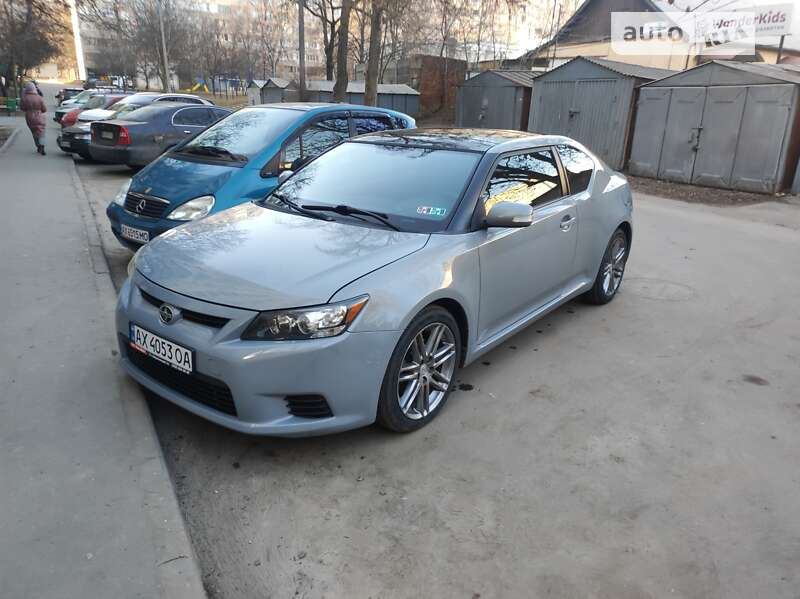

DETECTED NUMBER: AX4053OA


In [ ]:
def alpr(path="data/30231091.jpg"):
  img = cv2.imread(path)
  cv2_imshow(img)
  plate_img, bbox = get_box(img, model)
  with torch.no_grad():
      x = preprocess_image_hls(plate_img).to(device)
      logits = model_crnn(x)         
      text = ctc_greedy_decode(logits)[0]
      return text
print(f'DETECTED NUMBER: {alpr()}')
